<h1>Overview</h1>
This notebook focuses on predicting gold prices in INR using machine learning and time-series models. The workflow includes data collection, preprocessing, feature engineering, model training, evaluation, visualization, and deployment using Gradio. Below is an in-depth breakdown of its key components.

In [50]:
# Initializing all the Needed Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import gradio as gr

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV
from sklearn.linear_model import Ridge

In [52]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

1.Data Collection & Preprocessing

Data Source

The dataset consists of 53 weekly data points from 2024, including Date, USD/INR exchange rate, and Gold Rate in INR.

Retrieved from Exchange Rates.

In [53]:
gold_usdinr = pd.read_csv('../Data/Gold vs USDINR.csv')

In [54]:
gold_usdinr.head(5)

,Date,USD_INR,Goldrate
0,2024-01-01,83.240601,"₹5,066.31"
1,2024-01-08,83.076103,"₹4,966.31"
2,2024-01-15,83.160599,"₹5,015.33"
3,2024-01-22,83.146103,"₹4,950.84"
4,2024-01-29,82.927597,"₹4,976.77"


In [55]:

gold_usdinr.describe()

,USD_INR
count,53.000000
mean,83.717398
std,0.637302
min,82.752296
25%,83.301804
50%,83.544998
75%,83.988998
max,85.786598


In [56]:
gold_usdinr["Goldrate"] = gold_usdinr["Goldrate"].replace("₹",'',regex=True).replace(',','',regex=True).astype(float)

In [57]:
gold_usdinr.head(5)

,Date,USD_INR,Goldrate
0,2024-01-01,83.240601,5066.31
1,2024-01-08,83.076103,4966.31
2,2024-01-15,83.160599,5015.33
3,2024-01-22,83.146103,4950.84
4,2024-01-29,82.927597,4976.77


<h1>2.Exploratory Data Analysis (EDA)</h1>

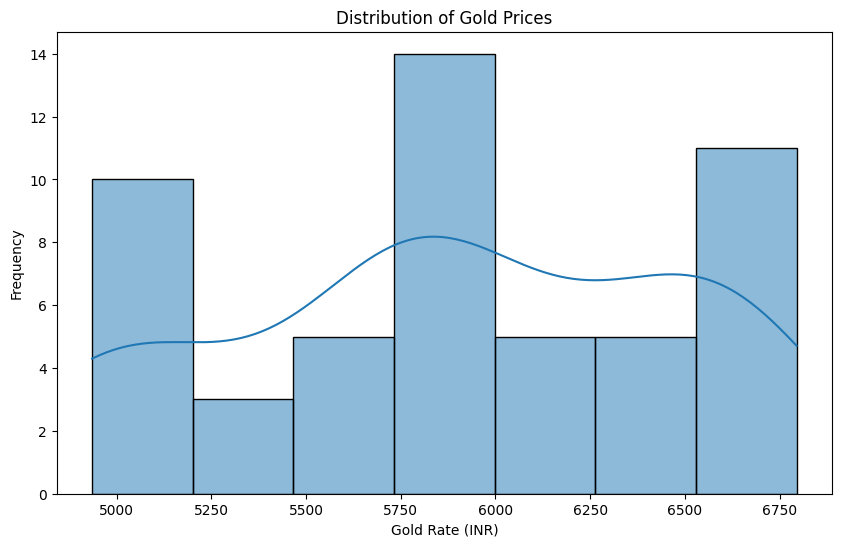

In [58]:
# Visualize the distribution of 'Goldrate'
plt.figure(figsize=(10, 6))
sns.histplot(gold_usdinr['Goldrate'], kde=True)
plt.title('Distribution of Gold Prices')
plt.xlabel('Gold Rate (INR)')
plt.ylabel('Frequency')
plt.show()

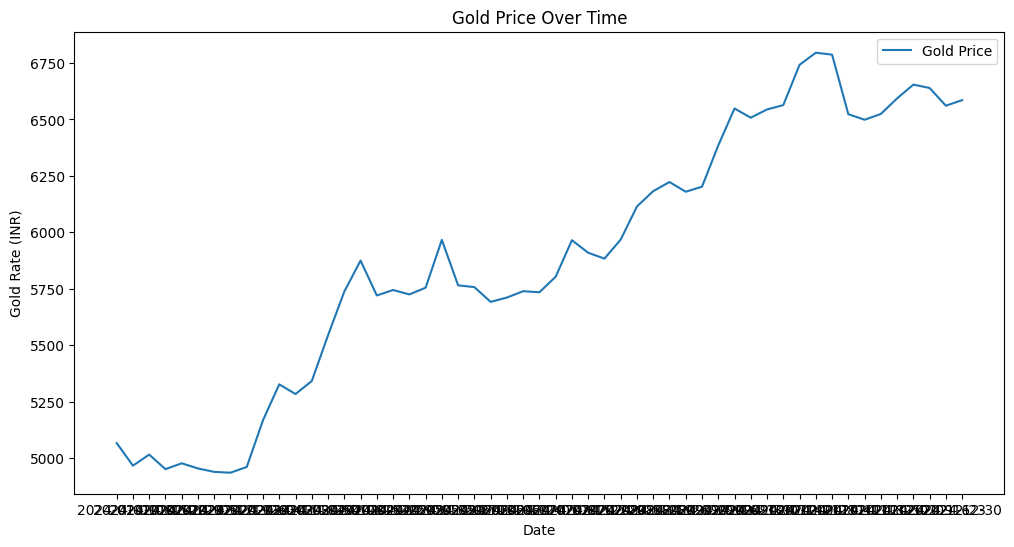

In [59]:

# Examine the relationship between gold prices and USDINR
plt.figure(figsize=(12,6))
sns.lineplot(data=gold_usdinr, x='Date', y='Goldrate', label='Gold Price')
plt.title('Gold Price Over Time')
plt.xlabel('Date')
plt.ylabel('Gold Rate (INR)')
plt.show()

<Axes: ylabel='USD_INR'>

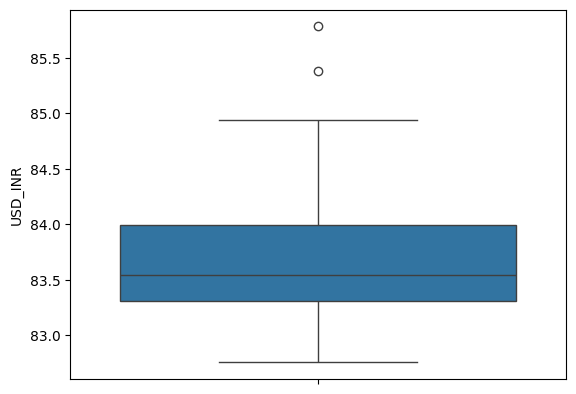

In [60]:

sns.boxplot(data=gold_usdinr['USD_INR'])

In [61]:
#Remove outliers

#Calculate IQR for USD_INR
Q1 = gold_usdinr['USD_INR'].quantile(0.25)
Q3 = gold_usdinr['USD_INR'].quantile(0.75)

# Define bounds for outliers

IQR = Q3-Q1
lower_bound = Q1-1.5*IQR
upper_bound = Q3+1.5*IQR

# Remove outliers based on the bounds
gold_usdinr_cleaned = gold_usdinr[
    (gold_usdinr['USD_INR'] >=lower_bound) &
    (gold_usdinr['USD_INR'] <=upper_bound)
]


In [62]:
# Print the number of outliers removed
print(f"Number of outliers removed: {len(gold_usdinr) - len(gold_usdinr_cleaned)}")

Number of outliers removed: 2


<Axes: ylabel='USD_INR'>

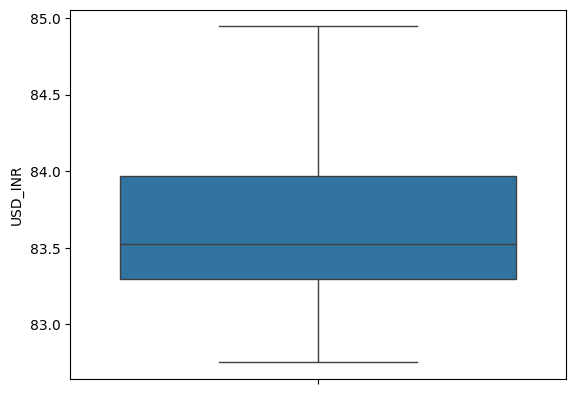

In [63]:
sns.boxplot(data=gold_usdinr_cleaned['USD_INR'])

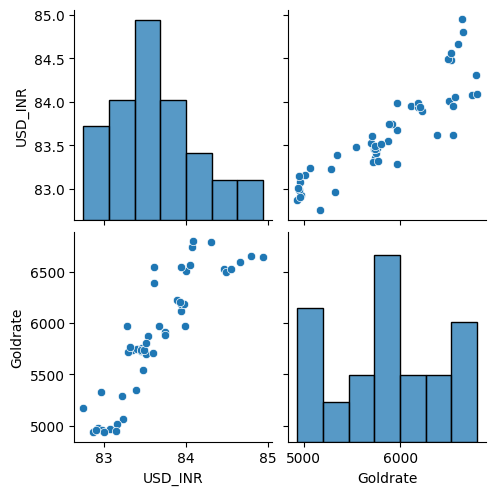

In [64]:
sns.pairplot(gold_usdinr_cleaned)

<Axes: xlabel='Goldrate', ylabel='USD_INR'>

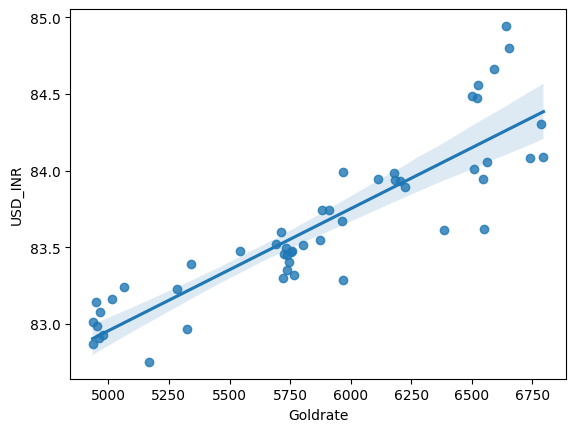

In [66]:
sns.regplot(x='Goldrate',y='USD_INR',data=gold_usdinr_cleaned)

<h1>3.Feature Engineering</h1>

* Extracted temporal features (e.g., day, month, year, day of the week) to capture seasonal trends.
* Standardized features before feeding them into machine learning models.
* Implemented feature selection to retain the most important attributes for prediction.

In [67]:
X = gold_usdinr_cleaned[['USD_INR']]
y = gold_usdinr_cleaned[['Goldrate']]

In [68]:
print(X.shape)
print(y.shape)

(51, 1)
(51, 1)


In [69]:

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [70]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(40, 1)
(11, 1)
(40, 1)
(11, 1)


In [71]:
#standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [72]:
X_train_scaled

array([[-1.28057948e+00],
       [ 2.15516837e+00],
       [-1.10040558e+00],
       [ 1.71016575e+00],
       [-1.24934489e+00],
       [ 5.80053355e-01],
       [ 5.90584978e-01],
       [-2.63986902e-01],
       [ 1.90814640e+00],
       [-1.27948818e-01],
       [-1.56774633e+00],
       [-5.69667239e-01],
       [-2.21666410e-01],
       [ 1.25499179e+00],
       [-2.98865962e-01],
       [-7.06259609e-01],
       [-6.80831281e-01],
       [ 1.55905082e+00],
       [-1.76075567e-01],
       [ 5.07953312e-01],
       [-1.14454139e+00],
       [ 2.34228128e-01],
       [-1.34762630e-03],
       [-9.79610650e-01],
       [-5.34982180e-01],
       [-8.26139974e-01],
       [ 7.15550994e-01],
       [ 6.68685278e-01],
       [-1.69534864e-01],
       [ 7.96201058e-01],
       [-1.18032120e+00],
       [-2.58540948e-01],
       [-2.83428831e-01],
       [ 2.41489758e+00],
       [-5.97645330e-01],
       [-1.34978333e+00],
       [ 8.47057712e-01],
       [-4.83404938e-01],
       [ 1.0

In [73]:
X_train.head(5)

,USD_INR
8,82.910400
49,84.802002
6,83.009598
47,84.556999
4,82.927597


In [74]:
X_test_scaled

array([[ 0.86467046],
       [ 0.60039603],
       [ 1.58537988],
       [-0.40402977],
       [-0.02514078],
       [ 0.67849631],
       [-0.37986245],
       [ 0.60458095],
       [-0.85246901],
       [ 0.23331354],
       [-0.25000479]])

<h1>4. Model Training & Evaluation</h1>

<h2>Models Implemented</h2>

1. Linear Regression – Basic baseline model.

2. Random Forest Regressor – Applied hyperparameter tuning with RandomizedSearchCV.

3. ARIMA – Time-series forecasting model.

<h1>1. Linear Regression Model</h1>

In [75]:
lin_reg = LinearRegression()

In [76]:
lin_reg.fit(X_train_scaled,y_train)

LinearRegression()

LinearRegression()

In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook.

On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org.

In [77]:
lin_reg.get_params()

{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}

In [78]:
y_pred = lin_reg.predict(X_test_scaled)
print(y_pred)
print(y_test)

[[6303.91716248]
 [6165.06820038]
 [6682.57563976]
 [5637.34602291]
 [5836.4131137 ]
 [6206.10184462]
 [5650.04345372]
 [6167.26694494]
 [5401.73744228]
 [5972.20420554]
 [5718.27026614]]
    Goldrate
43   6795.35
40   6544.00
46   6498.43
12   5341.21
24   5710.88
31   5967.66
17   5744.34
32   6114.39
3    4950.84
30   5883.33
13   5543.85


In [79]:
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R-squared: {r2}")

Mean Squared Error: 75693.83147343161
Root Mean Squared Error: 275.1251196699996
R-squared: 0.7244658615036521


In [80]:
#parameter tuning using randomizedsearchcv
# Define the parameter grid for RandomizedSearchCV
param_grid = {
    'alpha': np.logspace(-4, 4, 50),  # Explore a wide range of alpha values
    'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga'],  # Different solvers
    'fit_intercept': [True, False]  # Include or exclude the intercept
}
# Create a Ridge regression model
ridge = Ridge()

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=ridge,
    param_distributions=param_grid,
    n_iter=10,  # Number of random parameter combinations to try
    cv=5,  # Number of cross-validation folds
    scoring='neg_mean_squared_error',  # Use negative MSE as the scoring metric
    n_jobs=-1,  # Use all available CPU cores
    random_state=42,  # Set a random state for reproducibility
    verbose=2  # Set verbosity for output
)

In [81]:
# Fit the RandomizedSearchCV object to your training data
random_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END alpha=0.0062505519252739694, fit_intercept=True, solver=sparse_cg; total time=   0.0s
[CV] END alpha=0.0062505519252739694, fit_intercept=True, solver=sparse_cg; total time=   0.0s[CV] END alpha=0.0062505519252739694, fit_intercept=True, solver=sparse_cg; total time=   0.0s

[CV] END alpha=51.79474679231202, fit_intercept=False, solver=lsqr; total time=   0.0s
[CV] END alpha=51.79474679231202, fit_intercept=False, solver=lsqr; total time=   0.0s
[CV] END alpha=51.79474679231202, fit_intercept=False, solver=lsqr; total time=   0.0s
[CV] END alpha=51.79474679231202, fit_intercept=False, solver=lsqr; total time=   0.0s
[CV] END alpha=0.0062505519252739694, fit_intercept=True, solver=sparse_cg; total time=   0.0s
[CV] END alpha=51.79474679231202, fit_intercept=False, solver=lsqr; total time=   0.0s
[CV] END alpha=0.0062505519252739694, fit_intercept=True, solver=sparse_cg; total time=   0.0s
[CV] END alpha=3.727593720314

RandomizedSearchCV(cv=5, estimator=Ridge(), n_jobs=-1,
                   param_distributions={'alpha': array([1.00000000e-04, 1.45634848e-04, 2.12095089e-04, 3.08884360e-04,
       4.49843267e-04, 6.55128557e-04, 9.54095476e-04, 1.38949549e-03,
       2.02358965e-03, 2.94705170e-03, 4.29193426e-03, 6.25055193e-03,
       9.10298178e-03, 1.32571137e-02, 1.93069773e-02, 2.81176870e-02,
       4.09491506e-02, 5.96362...
       7.54312006e+01, 1.09854114e+02, 1.59985872e+02, 2.32995181e+02,
       3.39322177e+02, 4.94171336e+02, 7.19685673e+02, 1.04811313e+03,
       1.52641797e+03, 2.22299648e+03, 3.23745754e+03, 4.71486636e+03,
       6.86648845e+03, 1.00000000e+04]),
                                        'fit_intercept': [True, False],
                                        'solver': ['auto', 'svd', 'cholesky',
                                                   'lsqr', 'sparse_cg', 'sag',
                                                   'saga']},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

In [82]:
# Print the best hyperparameters found
print("Best hyperparameters:", random_search.best_params_)

Best hyperparameters: {'solver': 'saga', 'fit_intercept': True, 'alpha': 1.2067926406393288}


In [84]:
# Get the best model
best_ridge = random_search.best_estimator_
# Evaluate the best model on the test set
y_pred_best = best_ridge.predict(X_test_scaled)

In [85]:
# Calculate the metrics for the best model
mse_best = mean_squared_error(y_test, y_pred_best)
rmse_best = np.sqrt(mse_best)
r2_best = r2_score(y_test, y_pred_best)

print(f"Best Model Mean Squared Error: {mse_best}")
print(f"Best Model Root Mean Squared Error: {rmse_best}")
print(f"Best Model R-squared: {r2_best}")

Best Model Mean Squared Error: 77677.53838453042
Best Model Root Mean Squared Error: 278.70690408479373
Best Model R-squared: 0.7172449431786139


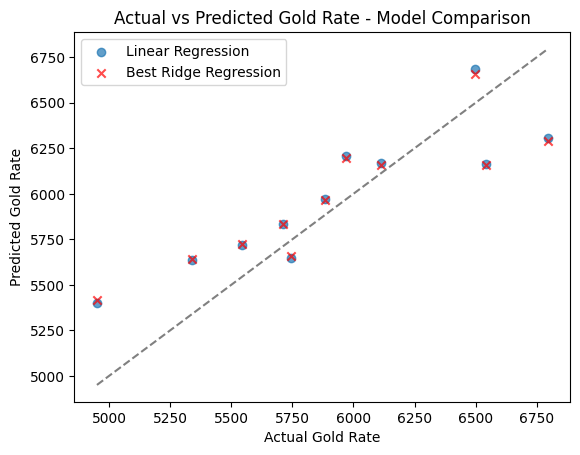

In [86]:

# comparing results of models through plots

import matplotlib.pyplot as plt

# Create a figure and an axes
fig, ax = plt.subplots()

# Plot the actual vs predicted values for the original linear regression model
ax.scatter(y_test, y_pred, label='Linear Regression', alpha=0.7)

# Plot the actual vs predicted values for the best Ridge regression model
ax.scatter(y_test, y_pred_best, label='Best Ridge Regression', alpha=0.7, marker='x', color='red')


# Add labels and title
ax.set_xlabel('Actual Gold Rate')
ax.set_ylabel('Predicted Gold Rate')
ax.set_title('Actual vs Predicted Gold Rate - Model Comparison')

# Add a legend
ax.legend()

# Add a diagonal line for reference
# Get the minimum and maximum values directly without indexing
min_value = min(y_test.min().values[0], y_pred.min(), y_pred_best.min())
max_value = max(y_test.max().values[0], y_pred.max(), y_pred_best.max())


ax.plot([min_value, max_value], [min_value, max_value], color='gray', linestyle='--')

# Show the plot
plt.show()